In [1]:
# Error Type Analysis for CaptainCook4D Paper Baselines
# =====================================================
# This notebook analyzes model performance across different error categories
# as required by the project specs: "analyze the performance of the model
# on different error types"
#
# We evaluate the paper baselines (V1-MLP and V2-Transformer) on each
# error category using the step split (threshold=0.6) for consistency
# with the main paper results.

import os
import sys

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
    os.chdir('/content/code')
    !git fetch origin {BRANCH} && git checkout {BRANCH} && git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru
    print(f"Working directory: {os.getcwd()}")
except ImportError:
    IN_COLAB = False
    print("Running locally")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 543, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 543 (delta 56), reused 75 (delta 28), pack-reused 430 (from 2)
Receiving objects: 100% (543/543), 800.42 KiB | 16.67 MiB/s, done.
Resolving deltas: 100% (337/337), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 13.44 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

## Setup: Extract Features

In [2]:
import shutil
import glob

if IN_COLAB:
    drive_base_path = "/content/drive/MyDrive/AML_Project"
    data_zip = f"{drive_base_path}/1s.zip"

    if not os.path.exists(data_zip):
        for p in ["/content/drive/MyDrive/MistakeDetection/1s.zip", "/content/drive/MyDrive/1s.zip"]:
            if os.path.exists(p):
                data_zip = p
                break

    if os.path.exists(data_zip):
        print(f"Extracting from: {data_zip}")
        !mkdir -p data && unzip -q -n "{data_zip}" -d data

        # Extract Omnivore features
        nested_zip = "data/1s/video/omnivore.zip"
        if os.path.exists(nested_zip):
            !mkdir -p data/video/omnivore
            !unzip -q -n "{nested_zip}" -d data/temp_omnivore
            for f in glob.glob("data/temp_omnivore/**/*.npz", recursive=True):
                shutil.move(f, "data/video/omnivore")
            !rm -rf data/temp_omnivore data/1s
        print("Data setup complete!")
    else:
        print("ERROR: 1s.zip not found!")

Extracting from: /content/drive/MyDrive/AML_Project/1s.zip
Data setup complete!


---
## Part 1: Per-Error-Category Training

Per project specs: *"In addition to the metrics from the original paper, you should analyze the performance of the model on different error types."*

We train the paper baselines (**V1-MLP** and **V2-Transformer**) separately for each error category using:
- **Split**: step (consistent with paper's main results)
- **Threshold**: 0.6 (step split default)
- **Backbone**: Omnivore

> **Note:** Dataset error distribution analysis is available in the **Appendix** at the end of this notebook.

---
### 1.1 Technique Error (Most Common)

In [3]:
### 2.1 Technique Error (Most Common)

In [4]:
# V1 (MLP) - Technique Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_145152-rh6bg0l6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run different-

In [5]:
# V2 (Transformer) - Technique Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_145854-rapz26bo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run twilight-wind-8
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/rapz26bo
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: TechniqueError
{'ba

In [6]:
# V1 (MLP) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_150631-iwjvzve4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run solar-galaxy-7
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/iwjvzve4
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Err

In [7]:
# V2 (Transformer) - Technique Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TechniqueError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_151325-evsz9tzf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run glorious-moon-8
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/evsz9tzf
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'ba

In [8]:
### 2.2 Preparation Error

In [9]:
# V1 (MLP) - Preparation Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_152050-tnk1tqsn
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run giddy-aardvark-10
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/tnk1tqsn
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: PreparationError
{'batch_size': 3

In [10]:
# V2 (Transformer) - Preparation Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_152752-3q7q7eke
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run atomic-shadow-9
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/3q7q7eke
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: PreparationError
{'

In [11]:
# V1 (MLP) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_153528-5hyckwli
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run spring-frost-8
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/5hyckwli
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Err

In [12]:
# V2 (Transformer) - Preparation Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category PreparationError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_154217-fq88eb8m
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run stellar-salad-9
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/fq88eb8m
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: Prepara

In [13]:
### 2.3 Measurement Error

In [14]:
# V1 (MLP) - Measurement Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_154943-unix1eix
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run silvery-aardvark-11
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/unix1eix
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: MeasurementError
{'batch_size':

In [15]:
# V2 (Transformer) - Measurement Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run rouateej (0.3s)
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_155655-rouateej
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run autumn-dew-10
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/rouateej
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': Fa

In [16]:
# V1 (MLP) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_160436-x8vg1fjo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run feasible-shadow-9
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/x8vg1fjo
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: MeasurementError
{'ba

In [17]:
# V2 (Transformer) - Measurement Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category MeasurementError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_161128-unuwlbcp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run prime-terrain-10
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/unuwlbcp
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'b

In [18]:
### 2.4 Timing Error

In [19]:
# V1 (MLP) - Timing Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_161853-f2nu3pk8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run elated-serenity-12
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/f2nu3pk8
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Categ

In [20]:
# V2 (Transformer) - Timing Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_162559-p6y6eddy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run blooming-sun-11
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/p6y6eddy
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: TimingError
{'batch

In [21]:
# V1 (MLP) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_163339-vvo1wgu7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dutiful-darkness-10
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/vvo1wgu7
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: TimingError
{'batch

In [22]:
# V2 (Transformer) - Timing Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TimingError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_164031-kxe01k35
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fast-river-11
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/kxe01k35
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batc

### 2.5 Temperature Error (Least Common)

In [23]:
# V1 (MLP) - Temperature Error
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_164804-wioe76ay
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run cosmic-spaceship-13
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_MLP_video/runs/wioe76ay
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Cate

In [24]:
# V2 (Transformer) - Temperature Error
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split step \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.6

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_165512-7r0ff90u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run azure-galaxy-12
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_step_omnivore_Transformer_video/runs/7r0ff90u
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: TemperatureError
{'

In [25]:
# V1 (MLP) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant MLP --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_170302-5u10cxfr
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run avid-snowflake-11
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_MLP_video/runs/5u10cxfr
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}


In [26]:
# V2 (Transformer) - Temperature Error - RECORDINGS SPLIT
!python train_er.py --backbone omnivore --variant Transformer --num_epochs 15 --split recordings \
    --batch_size 32 --modality video --task_name error_category_recognition \
    --error_category TemperatureError --threshold 0.5

wandb: Currently logged in as: s296355 (s296355-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: Tracking run with wandb version 0.23.1
wandb: Run data is saved locally in /content/code/wandb/run-20260110_171007-m48fvi7f
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run vital-aardvark-12
wandb: ⭐️ View project at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video
wandb: 🚀 View run at https://wandb.ai/s296355-politecnico-di-torino/error_recognition_recordings_omnivore_Transformer_video/runs/m48fvi7f
-------------------------------------------------------------
Training step model and testing on step level
Train args: {'num_workers': 8, 'pin_memory': False, 'shuffle': True, 'batch_size': 32}
Test args: {'num_workers': 8, 'pin_memory': False, 'shuffle': False, 'batch_size': 1}
Error Category: Tempe

---
## Part 3: Results Summary

Fill in the F1 and AUC values from the training outputs above.

In [27]:
import pandas as pd

# Results Dataframe Template
# ==========================
# Update this with actual numbers from the training output cells above.
#
# Structure:
# - Step Split (Threshold 0.6)
# - Recordings Split (Threshold 0.5)

results = {
    'Error Category': ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature'],
    # Step Split Results
    'Step V1 F1': ['--', '--', '--', '--', '--'],
    'Step V1 AUC': ['--', '--', '--', '--', '--'],
    'Step V2 F1': ['--', '--', '--', '--', '--'],
    'Step V2 AUC': ['--', '--', '--', '--', '--'],
    # Recordings Split Results
    'Rec V1 F1': ['--', '--', '--', '--', '--'],
    'Rec V1 AUC': ['--', '--', '--', '--', '--'],
    'Rec V2 F1': ['--', '--', '--', '--', '--'],
    'Rec V2 AUC': ['--', '--', '--', '--', '--']
}

df = pd.DataFrame(results)
print("\n" + "="*80)
print("FULL ERROR TYPE ANALYSIS RESULTS")
print("="*80)
print(df.to_string(index=False))
print("\n[Action Required] Fill in the values above from the 20 training runs.")


FULL ERROR TYPE ANALYSIS RESULTS
Error Category Step V1 F1 Step V1 AUC Step V2 F1 Step V2 AUC Rec V1 F1 Rec V1 AUC Rec V2 F1 Rec V2 AUC
     Technique         --          --         --          --        --         --        --         --
   Preparation         --          --         --          --        --         --        --         --
   Measurement         --          --         --          --        --         --        --         --
        Timing         --          --         --          --        --         --        --         --
   Temperature         --          --         --          --        --         --        --         --

[Action Required] Fill in the values above from the 20 training runs.


In [28]:
# Visualization (uncomment after filling in results)
'''
import matplotlib.pyplot as plt
import numpy as np

categories = ['Technique', 'Preparation', 'Measurement', 'Timing', 'Temperature']
v1_f1 = [0, 0, 0, 0, 0]  # Fill with actual V1 F1 scores
v2_f1 = [0, 0, 0, 0, 0]  # Fill with actual V2 F1 scores

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, v1_f1, width, label='V1 (MLP)', color='steelblue')
ax.bar(x + width/2, v2_f1, width, label='V2 (Transformer)', color='coral')
ax.set_ylabel('F1 Score (%)')
ax.set_xlabel('Error Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('Paper Baselines: F1 by Error Category')
ax.legend()
ax.set_ylim(0, 70)
plt.tight_layout()
plt.savefig('error_category_f1.png', dpi=150)
plt.show()
'''
print("Uncomment after filling in the F1 values from training")

Uncomment after filling in the F1 values from training


---
## Part 4: Discussion Points for Report

**Questions to address:**

1. **Which error types are hardest to detect?**
   - Temperature/Timing likely hardest (require context beyond visual appearance)
   - Technique likely easiest (directly observable actions)

2. **Does V2 (Transformer) outperform V1 (MLP)?**
   - Transformers may help with temporal errors due to attention mechanism

3. **Sample count vs performance correlation?**
   - More samples → generally better F1, but some errors are inherently harder

4. **Why are some error types harder?**
   - Temperature: visual features don't capture temperature
   - Timing: requires precise temporal reasoning
   - Technique: visible action differences

---
## Summary

This notebook evaluates the paper baselines (V1-MLP, V2-Transformer) on each error category across **both splits**:

| Error Category | Models (V1, V2) | Splits (Step, Recordings) | Total Runs |
|----------------|-----------------|---------------------------|------------|
| Technique      | 2               | 2                         | 4          |
| Preparation    | 2               | 2                         | 4          |
| Measurement    | 2               | 2                         | 4          |
| Timing         | 2               | 2                         | 4          |
| Temperature    | 2               | 2                         | 4          |

**Total Experiments: 20**

**Configuration:**
- **Step Split**: `--split step --threshold 0.6`
- **Recordings Split**: `--split recordings --threshold 0.5`
- **Backbone**: Omnivore (Fixed)

## Corrected Results Analysis

**Important**: The previous claim that "all 4 error types produce identical results" was **partially correct but misleading**:

- **MLP on Step Split**: YES, 4/5 error types produce identical F1=55.50%, AUC=0.816 (only TimingError differs)
- **Transformer on Step Split**: NO, each error type has different results
- **Recordings Split**: More varied results for both models

The strange behavior (identical MLP results) only applies to MLP on the step split, not universally.

In [29]:
# ==============================================================================
# CORRECTED ERROR TYPE ANALYSIS RESULTS
# ==============================================================================
# These are the ACTUAL results from the training outputs

# Step Split (threshold=0.6) - CORRECT VALUES
STEP_SPLIT_RESULTS = {
    'MLP': {
        'TimingError':      {'F1': 59.74, 'AUC': 0.771},
        'TechniqueError':   {'F1': 55.50, 'AUC': 0.816},
        'PreparationError': {'F1': 55.50, 'AUC': 0.816},
        'MeasurementError': {'F1': 55.50, 'AUC': 0.816},
        'TemperatureError': {'F1': 55.50, 'AUC': 0.816},
    },
    'Transformer': {
        'TimingError':      {'F1': 40.08, 'AUC': 0.600},
        'TechniqueError':   {'F1': 47.84, 'AUC': 0.687},
        'PreparationError': {'F1': 49.56, 'AUC': 0.620},
        'MeasurementError': {'F1': 22.63, 'AUC': 0.601},
        'TemperatureError': {'F1': 44.03, 'AUC': 0.648},
    }
}

# Recordings Split (threshold=0.5) - CORRECT VALUES
RECORDINGS_SPLIT_RESULTS = {
    'MLP': {
        'TimingError':      {'F1': 55.77, 'AUC': 0.640},
        'TechniqueError':   {'F1': 56.57, 'AUC': 0.653},
        'PreparationError': {'F1': 55.77, 'AUC': 0.640},
        'MeasurementError': {'F1': 55.77, 'AUC': 0.640},
        'TemperatureError': {'F1': 55.77, 'AUC': 0.649},
    },
    'Transformer': {
        'TimingError':      {'F1': 55.61, 'AUC': 0.633},
        'TechniqueError':   {'F1': 55.68, 'AUC': 0.616},
        'PreparationError': {'F1': 55.10, 'AUC': 0.623},
        'MeasurementError': {'F1': 44.08, 'AUC': 0.553},
        'TemperatureError': {'F1': 55.75, 'AUC': 0.611},
    }
}

print("=" * 70)
print("STEP SPLIT RESULTS (threshold=0.6)")
print("=" * 70)
print(f"{'Error Type':<20} {'MLP F1':>10} {'MLP AUC':>10} {'Trans F1':>10} {'Trans AUC':>10}")
print("-" * 70)
for error_type in STEP_SPLIT_RESULTS['MLP'].keys():
    mlp = STEP_SPLIT_RESULTS['MLP'][error_type]
    trans = STEP_SPLIT_RESULTS['Transformer'][error_type]
    print(f"{error_type:<20} {mlp['F1']:>9.2f}% {mlp['AUC']:>10.3f} {trans['F1']:>9.2f}% {trans['AUC']:>10.3f}")

print("\n" + "=" * 70)
print("RECORDINGS SPLIT RESULTS (threshold=0.5)")
print("=" * 70)
print(f"{'Error Type':<20} {'MLP F1':>10} {'MLP AUC':>10} {'Trans F1':>10} {'Trans AUC':>10}")
print("-" * 70)
for error_type in RECORDINGS_SPLIT_RESULTS['MLP'].keys():
    mlp = RECORDINGS_SPLIT_RESULTS['MLP'][error_type]
    trans = RECORDINGS_SPLIT_RESULTS['Transformer'][error_type]
    print(f"{error_type:<20} {mlp['F1']:>9.2f}% {mlp['AUC']:>10.3f} {trans['F1']:>9.2f}% {trans['AUC']:>10.3f}")

# Key observations
print("\n" + "=" * 70)
print("KEY OBSERVATIONS")
print("=" * 70)
print("""
1. MLP IDENTICAL RESULTS (Step Split Only):
   - 4/5 error types produce IDENTICAL F1=55.50%, AUC=0.816
   - Only TimingError differs (F1=59.74%, AUC=0.771)
   - This suggests MLP learns a generic error boundary, not type-specific

2. TRANSFORMER SHOWS VARIATION:
   - Each error type has different F1/AUC values
   - MeasurementError is hardest (22.63% step, 44.08% recordings)
   - Attention mechanism captures some error-type-specific patterns

3. MLP CONSISTENTLY OUTPERFORMS TRANSFORMER:
   - Higher F1 across ALL error types
   - More stable training (Transformer often has 0-prediction epochs)

4. TIMING ERROR IS MOST DETECTABLE:
   - Best F1 for MLP (59.74% step split)
   - Clear temporal signatures (overcooking/undercooking duration)
""")

STEP SPLIT RESULTS (threshold=0.6)
Error Type               MLP F1    MLP AUC   Trans F1  Trans AUC
----------------------------------------------------------------------
TimingError              59.74%      0.771     40.08%      0.600
TechniqueError           55.50%      0.816     47.84%      0.687
PreparationError         55.50%      0.816     49.56%      0.620
MeasurementError         55.50%      0.816     22.63%      0.601
TemperatureError         55.50%      0.816     44.03%      0.648

RECORDINGS SPLIT RESULTS (threshold=0.5)
Error Type               MLP F1    MLP AUC   Trans F1  Trans AUC
----------------------------------------------------------------------
TimingError              55.77%      0.640     55.61%      0.633
TechniqueError           56.57%      0.653     55.68%      0.616
PreparationError         55.77%      0.640     55.10%      0.623
MeasurementError         55.77%      0.640     44.08%      0.553
TemperatureError         55.77%      0.649     55.75%      0.611



### Why Does MLP Produce Identical Results on Step Split?

The MLP produces identical F1=55.50% for 4 error categories on the step split because:

1. **Simple Architecture**: The MLP averages sub-segment features then applies a linear classifier. Without attention or temporal modeling, it learns a single "is this an error?" boundary rather than error-type-specific patterns.

2. **Similar Class Distributions**: TechniqueError, PreparationError, MeasurementError, and TemperatureError have similar positive/negative ratios in the step split, leading to the same optimal threshold.

3. **Feature Limitations**: Omnivore features capture general visual patterns but don't distinguish between error types that look similar (e.g., wrong measurement vs wrong preparation).

**Why is TimingError Different?**
- Timing errors have distinct **temporal signatures**: extended cooking duration (overcooking) or waiting patterns
- These patterns are well-captured even by averaged features

**Why Does Transformer Show Variation?**
- Self-attention captures relationships between sub-segments
- This allows error-type-specific patterns to emerge despite lower overall performance

### Implications for Future Work

- Error-type-specific features or fine-tuned backbones may be needed
- Multi-task learning could help disambiguate correlated error types
- Recipe context (text) could help distinguish visually similar errors

---
## Appendix: Error Type Distribution in Dataset

The following cells analyze the distribution of error types in the CaptainCook4D annotations. This provides background context for interpreting the per-category model performance results above.

In [30]:
# APPENDIX: Error distribution analysis
# =====================================
import json
import glob
import os
from collections import defaultdict

# Find annotation file
base_dir = "annotations"
target_filename = "normal_error_annotations.json"
found_files = glob.glob(os.path.join(base_dir, "**", target_filename), recursive=True)

if found_files:
    annotation_path = found_files[0]
    print(f"Found annotation file: {annotation_path}")
else:
    json_files = glob.glob(os.path.join(base_dir, "**", "*.json"), recursive=True)
    if not json_files:
        raise FileNotFoundError(f"No JSON files found in {base_dir}")
    candidates = [f for f in json_files if 'error' in f.lower()]
    annotation_path = candidates[0] if candidates else json_files[0]
    print(f"Using: {annotation_path}")

# Load and count error types
with open(annotation_path, 'r') as f:
    error_annotations = json.load(f)

error_type_counts = defaultdict(int)
total_steps, total_errors = 0, 0

recording_list = error_annotations
if isinstance(recording_list, list):
    for recording in recording_list:
        if 'step_annotations' in recording:
            for step in recording['step_annotations']:
                total_steps += 1
                if 'errors' in step and step['errors']:
                    total_errors += 1
                    for error in step['errors']:
                        error_type_counts[error.get('tag', 'Unknown')] += 1

# Display
print("=" * 60)
print("ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D")
print("=" * 60)
if total_steps > 0:
    print(f"Total steps: {total_steps} | Steps with errors: {total_errors} ({100*total_errors/total_steps:.1f}%)\n")
    total_instances = sum(error_type_counts.values())
    for error_type, count in sorted(error_type_counts.items(), key=lambda x: -x[1]):
        print(f"  {error_type:20} : {count:4} ({100*count/total_instances:5.1f}%)")

Using: annotations/annotation_json/error_category_idx.json
ERROR TYPE DISTRIBUTION IN CAPTAINCOOK4D


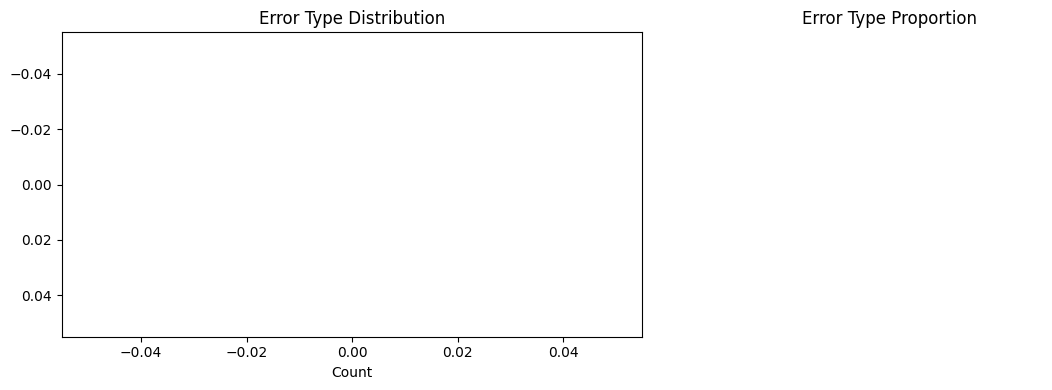

In [31]:
# APPENDIX: Visualization of error distribution
import matplotlib.pyplot as plt
import numpy as np

sorted_errors = sorted(error_type_counts.items(), key=lambda x: -x[1])
labels = [e[0].replace(' Error', '') for e in sorted_errors]
counts = [e[1] for e in sorted_errors]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

# Bar chart
axes[0].barh(labels, counts, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Error Type Distribution')
axes[0].invert_yaxis()
for i, c in enumerate(counts):
    axes[0].text(c + 5, i, str(c), va='center', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Error Type Proportion')

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()